HOUSING


In [22]:
# Rashi Pande
# 23070521177
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [6]:
import zipfile
import os

zip_file_path = '/content/archive (1).zip'
extraction_directory = '/content/'

# Check if the zip file exists and extract its contents
if os.path.exists(zip_file_path):
    print(f"Extracting {zip_file_path}...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_directory)
        print("Extraction complete.")
    except Exception as e:
        print(f"Error during extraction: {e}")
else:
    print(f"Zip file not found at {zip_file_path}. Please ensure it is uploaded.")

df = pd.read_csv('/content/Housing.csv')

Extracting /content/archive (1).zip...
Extraction complete.


In [7]:
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

First 5 Rows
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape
(545, 13)

Column Names
Index(['price', 'area', 'bedrooms', 'bathrooms'

In [8]:
categorical_columns = df.select_dtypes(include=['object']).columns

le = LabelEncoder()

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  


In [9]:
X = df.drop('price', axis=1)
y = df['price']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (545, 12)
Target Shape : (545,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(1)

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 25349385617408.0000 - mae: 4727421.5000 - val_loss: 24781590102016.0000 - val_mae: 4623896.5000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 25349368840192.0000 - mae: 4727420.0000 - val_loss: 24781564936192.0000 - val_mae: 4623894.0000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 25349335285760.0000 - mae: 4727416.0000 - val_loss: 24781512507392.0000 - val_mae: 4623888.5000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 25349263982592.0000 - mae: 4727409.5000 - val_loss: 24781409746944.0000 - val_mae: 4623878.5000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 25349133959168.0000 - mae: 4727395.5000 - val_loss: 24781229391872.0000 - val_mae: 4623860.5000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 25348888592384.0000 - mae: 4727372.5000 - val_loss: 24780900139008.0000 - val_mae: 4623828.5000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2534

In [15]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test MAE :", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5747225133056.0000 - mae: 2078917.6250
Test Loss : 5747225133056.0
Test MAE : 2078917.625


In [16]:
predictions = model.predict(X_test)

predictions = predictions.flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [17]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 2078917.625
Mean Squared Error (MSE): 5747224608768.0
Root Mean Squared Error (RMSE): 2397336.98273063


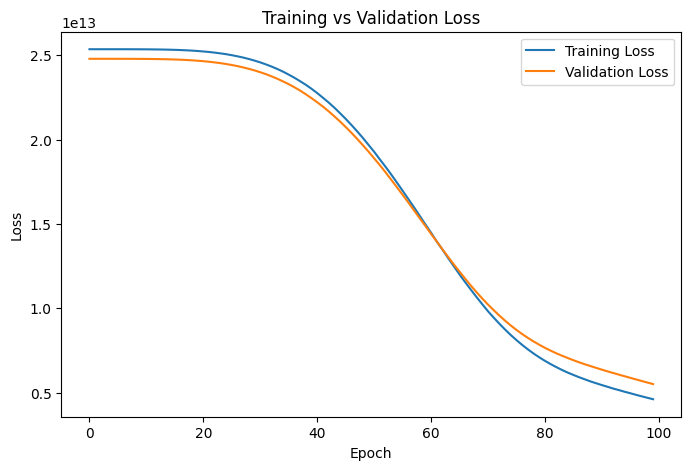

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

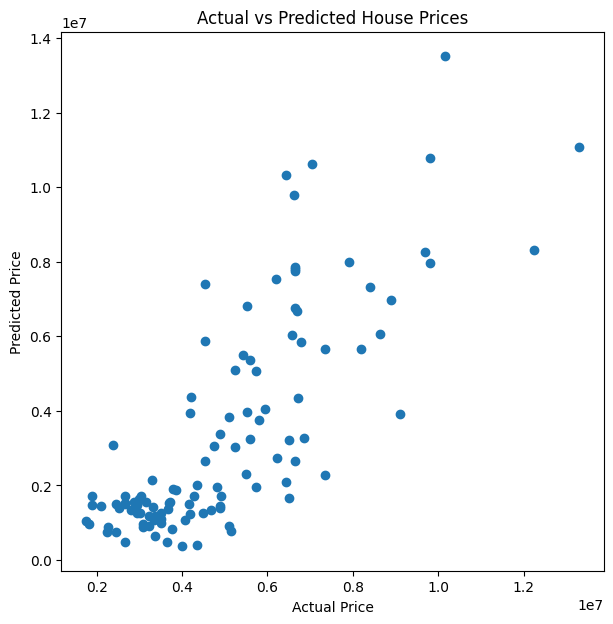

In [19]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [20]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [21]:
model = Sequential([
    Input(shape=(8,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])